In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/raw/gym_gesture/imu_dataset.csv')
df.head()

,athlete_id,exercise_type,weight_kg,set_number,rep_number,timestamp,ax,ay,az,gx,gy,gz
0,1,chest_fly,17.5,1,1,1092989,0.851126,0.611812,1.629094,73.564087,41.816406,-24.615479
1,1,chest_fly,17.5,1,1,1092999,0.163992,0.276973,1.134953,-15.913452,-9.392090,4.254150
2,1,chest_fly,17.5,1,1,1093009,0.187064,0.192744,1.101994,-17.134155,1.105957,4.803467
3,1,chest_fly,17.5,1,1,1093019,0.171927,0.180049,1.076725,-13.349976,4.401855,6.085205
4,1,chest_fly,17.5,1,1,1093029,0.147269,0.200923,1.071476,-8.345093,2.692871,7.489014


In [3]:
# 列名
df.columns.tolist()

['athlete_id',
 'exercise_type',
 'weight_kg',
 'set_number',
 'rep_number',
 'timestamp',
 'ax',
 'ay',
 'az',
 'gx',
 'gy',
 'gz']

In [4]:
# 行数和列数
df.shape

(150000, 12)

In [5]:
# 所有动作类别及其数量（确保能看到全部）
df['exercise_type'].value_counts()

exercise_type
chest_fly           30000
chest_press         30000
lat_pulldown        30000
seated_row          30000
tricep_extension    30000
Name: count, dtype: int64

In [6]:
rename_dict = {
    'ax': 'acc_x',
    'ay': 'acc_y',
    'az': 'acc_z',
    'gx': 'gyro_x',
    'gy': 'gyro_y',
    'gz': 'gyro_z',
    'athlete_id': 'subject_id',
    'exercise_type': 'label'
}
df.rename(columns=rename_dict, inplace=True)
df = df[['label', 'subject_id', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']]
df.head()

,label,subject_id,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z
0,chest_fly,1,0.851126,0.611812,1.629094,73.564087,41.816406,-24.615479
1,chest_fly,1,0.163992,0.276973,1.134953,-15.913452,-9.392090,4.254150
2,chest_fly,1,0.187064,0.192744,1.101994,-17.134155,1.105957,4.803467
3,chest_fly,1,0.171927,0.180049,1.076725,-13.349976,4.401855,6.085205
4,chest_fly,1,0.147269,0.200923,1.071476,-8.345093,2.692871,7.489014


第一个动作： chest_fly


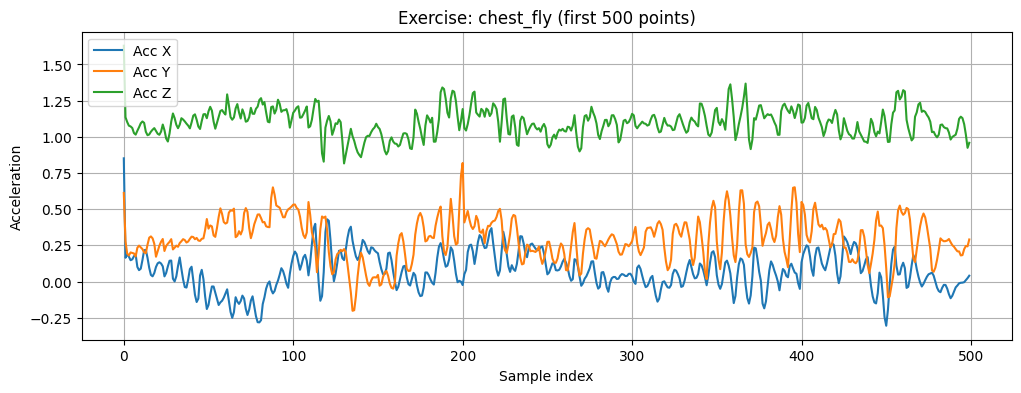

In [7]:
first_label = df['label'].iloc[0]
print('第一个动作：', first_label)

df_action = df[df['label'] == first_label].head(500)

plt.figure(figsize=(12,4))
plt.plot(df_action['acc_x'].values, label='Acc X')
plt.plot(df_action['acc_y'].values, label='Acc Y')
plt.plot(df_action['acc_z'].values, label='Acc Z')
plt.title(f'Exercise: {first_label} (first 500 points)')
plt.xlabel('Sample index')
plt.ylabel('Acceleration')
plt.legend()
plt.grid(True)
plt.show()